<a href="https://colab.research.google.com/github/miftahulhdd/MiftahulHudaAmri_2411533005_ML2526/blob/main/praktikum7/tugasdecisiontree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

In [ ]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
tree_default = DecisionTreeClassifier(random_state=42)
tree_default.fit(X_train, y_train)

y_train_pred = tree_default.predict(X_train)
y_test_pred = tree_default.predict(X_test)

print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy :", accuracy_score(y_test, y_test_pred))

Train Accuracy: 1.0
Test Accuracy : 0.9473684210526315


uji max depth hingga 30

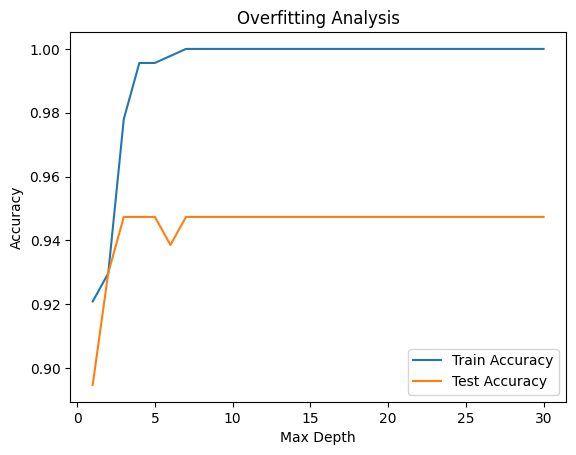

In [ ]:
depths = range(1, 31)

train_acc = []
test_acc = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)

    train_acc.append(accuracy_score(y_train, model.predict(X_train)))
    test_acc.append(accuracy_score(y_test, model.predict(X_test)))

plt.plot(depths, train_acc, label="Train Accuracy")
plt.plot(depths, test_acc, label="Test Accuracy")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Overfitting Analysis")
plt.show()

In [ ]:
tree_tuned = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=10,
    random_state=42
)

tree_tuned.fit(X_train, y_train)

y_train_pred = tree_tuned.predict(X_train)
y_test_pred = tree_tuned.predict(X_test)

print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy :", accuracy_score(y_test, y_test_pred))

Train Accuracy: 0.9582417582417583
Test Accuracy : 0.9473684210526315


In [ ]:
logreg = LogisticRegression(max_iter=5000, random_state=42)

logreg.fit(X_train, y_train)

y_train_pred_logreg = logreg.predict(X_train)
y_test_pred_logreg = logreg.predict(X_test)

print("Train Accuracy:", accuracy_score(y_train, y_train_pred_logreg))
print("Test Accuracy :", accuracy_score(y_test, y_test_pred_logreg))

Train Accuracy: 0.9582417582417583
Test Accuracy : 0.956140350877193


In [ ]:
tree_cv = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

cv_scores = cross_val_score(
    tree_cv,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("CV score:", cv_scores)
print("Rata-rata Accuracy:", cv_scores.mean())

CV score: [0.92105263 0.89473684 0.95614035 0.94736842 0.9380531 ]
Rata-rata Accuracy: 0.9314702685918336


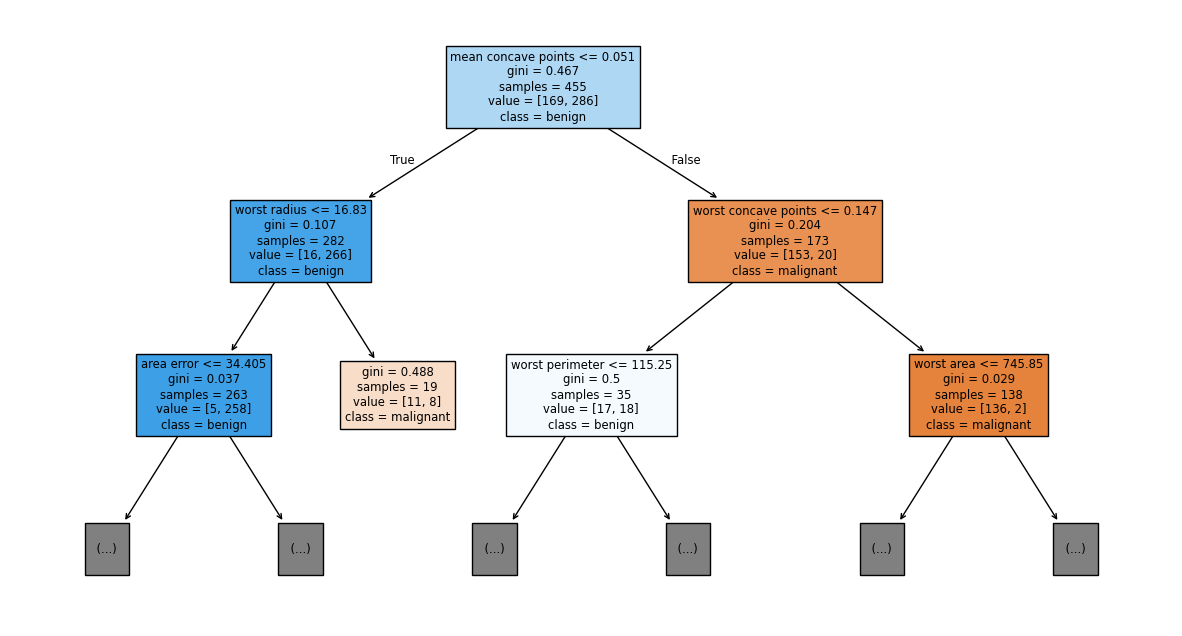

In [ ]:
plt.figure(figsize=(15,8))
plot_tree(
    tree_tuned,
    feature_names=X.columns,
    class_names=data.target_names,
    filled=True,
    max_depth=2
)
plt.show()